# Case Study 1: Predicting Superconductor Critical Temperature
### Eric Graham
### DS 7333: Quantifying the World
### Dr. Robert Slater


## Introduction

For this case study, we are presented with a dataset of 21,263 superconducting materials, each described by 81 engineered features derived from the elements that make up those compounds. Our goal is to predict each material's critical temperature (the temperature at which it becomes superconductive) using linear regression models with L1 (Lasso) and L2 (Ridge) regularization. We will compare the performance of both models and identify the ten most important features driving each model's predictions.

## Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error

# note: L1 had trouble converging on a value for lambda, so I suppressed warnings to make the output doc more readable
import warnings
warnings.filterwarnings('ignore')

print(f"pandas:     {pd.__version__}")
print(f"numpy:      {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"sklearn:    {sklearn.__version__}")

pandas:     3.0.3
numpy:      2.4.4
matplotlib: 3.10.9
sklearn:    1.8.0


## Read In Data

In [2]:
df = pd.read_csv("data/train.csv")
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie                         21263 non-null  float64
 12  wtd_mean_fie                 

## Exploratory Data Analysis

Before setting up the data pipeline and fitting the model, we want to do a quick missingness check and look at the distribution of the target variable.

### Missingness Check

Although introductory videos for Case Study 1 indicate that there is no missing data, it's prudent to always do some sort of check for missing values.

In [4]:
df.isnull().sum().sum()

np.int64(0)

### Distribution of Target Variable

As shown in the histogram below, our target variable (critical_temp) is heavily right-skewed, with the majority of observations having a critical temperature near 0. This skewness in the target variable can bias the model towards lower temperatures. One approach to this would be to try a log transformation on the target variable, but that introduces additional complexity to a project which emphasizes interpretability, so we proceed with the untransformed target variable to remain consistent with the modeling approach demonstrated in the course materials.

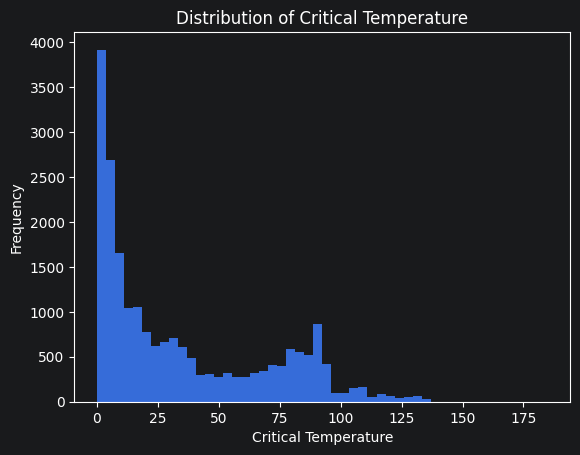

In [5]:
plt.hist(df['critical_temp'], bins=50)
plt.xlabel('Critical Temperature')
plt.ylabel('Frequency')
plt.title('Distribution of Critical Temperature')
plt.show()

## Preprocessing

First, we identify the features (X) and target variable (y). Then, we create an 80/20 train/test split and fit our scaler to the training data. This simulates real-world conditions in which you wouldn't be able to fit a scaler to the unknown data that you are predicting against.


In [6]:
X = df.drop(columns='critical_temp')
y = df['critical_temp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Plain Linear Baseline

Strictly for the purposes of comparison, we include an unmodified linear model with all features to serve as a baseline. The MSE of 302.0075 is really only interpretable when compared to other models, but by taking the RMSE we can see that, on average, we're off by 17.3784 degrees. Given the range of temperatures (0 to ~185) I think we can do better than that!

In [7]:
from sklearn.linear_model import LinearRegression

baseline = LinearRegression()
baseline.fit(X_train_scaled, y_train)
baseline_preds = baseline.predict(X_test_scaled)
baseline_mse = mean_squared_error(y_test, baseline_preds)
print(f"Baseline MSE: {baseline_mse:.4f}")
print(f"Baseline RMSE: {np.sqrt(baseline_mse):.4f}")

Baseline MSE: 302.0075
Baseline RMSE: 17.3784


In [8]:
results = {}
results['Baseline'] = {'MSE': baseline_mse, 'RMSE': np.sqrt(baseline_mse)}

## L1 (LASSO) Regression

L1 regression's penalty term is the absolute value of the coefficients.

$$J = \frac{1}{n} \sum_{i=1}^{n} \left(Y_i - \sum_{j=0}^{k} m_j x_{ij}\right)^2 + \lambda \sum_{j=0}^{k} |m_j|$$

This has the effect of reducing coefficients for the least predictive features to zero, reducing the number of features in the model (sparsity). This makes it a powerful option for feature selection and interpretability at the expense of predictive power: the features that L1 effectively removes from the model can still carry some predictive signal.

### Finding Lambda for L1

Lambda is the critical hyperparameter that we tune here: as shown in the example notebook, we use the logspace function from numpy to generate 25 lambda values across a logarithmic range. We initialize placeholders for the best score and best lambda value before looping through the 25 generated lambda values using 5-fold cross-validation (which adds another layer of rigor in our effort to find the most generalizable model). The best lambda value found in this process is then used in our fitted model, which we run against the test data.

In [9]:
lambdas = np.logspace(-3, 3, 25)
best_score = -1e99
best_lambda = -1

for lam in lambdas:
    model = Lasso(alpha=lam)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    if scores.mean() > best_score:
        best_score = scores.mean()
        best_lambda = lam

print(f"Best alpha: {best_lambda:.6f}")
print(f"Best CV MSE: {-best_score:.4f}")

Best alpha: 0.001000
Best CV MSE: 315.6026


This model had difficulty converging on a best value for lambda, even after tightening the range of the logspace. It settled on a best alpha of 0.001, which suggests that very little regularization is optimal for L1 on this dataset.

The best lambda we found (0.001) is so small that we are very close to the coefficients of the baseline model, and the fitted model with this lambda performs comparably to the baseline on our test data (RMSE of 17.48). This suggests that the weak regularization did little to improve on ordinary linear regression.

In [10]:
lasso = Lasso(alpha=best_lambda)
lasso.fit(X_train_scaled, y_train)
lasso_preds = lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_preds)
print(f"LASSO MSE: {lasso_mse:.4f}")
print(f"LASSO RMSE: {np.sqrt(lasso_mse):.4f}")

LASSO MSE: 305.5835
LASSO RMSE: 17.4809


In [11]:
results['Lasso'] = {'MSE': lasso_mse, 'RMSE': np.sqrt(lasso_mse)}

## L2 (Ridge) Regression

L2 regression's penalty term is the squared value of the coefficients.

$$J = \frac{1}{n} \sum_{i=1}^{n} \left(Y_i - \sum_{j=0}^{k} m_j x_{ij}\right)^2 + \lambda \sum_{j=0}^{k} m_j^2$$

Unlike L1, L2 shrinks all coefficients _towards_ zero without reducing any to zero. This means all features remain in the model, allowing even weak predictors to contribute their signal. This makes Ridge the stronger choice for predictive accuracy, though it means it isn't useful for feature selection and we sacrifice some of L1's interpretability by leaving in every feature.

We take the same approach to finding the best lambda value for L2 as we did for L1.

In [12]:
lambdas = np.logspace(-3, 3, 25)
best_score = -1e99
best_lambda = -1

for lam in lambdas:
    model = Ridge(alpha=lam)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    if scores.mean() > best_score:
        best_score = scores.mean()
        best_lambda = lam

print(f"Best alpha: {best_lambda:.6f}")
print(f"Best CV MSE: {-best_score:.4f}")

Best alpha: 0.100000
Best CV MSE: 313.3271


L2 converged cleanly with no warnings, settling on a best alpha of 0.1, a more impactful level of regularization than L1's 0.001. The fitted Ridge model (α = 0.1) performs nearly identically to the baseline when run agaisnt our test data (RMSE of 17.38). While L2 found a more meaningful level of regularization than L1, the marginal improvement suggests that for this dataset, regularization doesn't have a significant impact on prediction error.

In [13]:
ridge = Ridge(alpha=best_lambda)
ridge.fit(X_train_scaled, y_train)
ridge_preds = ridge.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_preds)
print(f"Ridge MSE: {ridge_mse:.4f}")
print(f"Ridge RMSE: {np.sqrt(ridge_mse):.4f}")

Ridge MSE: 302.1473
Ridge RMSE: 17.3824


In [14]:
results['Ridge'] = {'MSE': ridge_mse, 'RMSE': np.sqrt(ridge_mse)}

In [15]:
print(results)

{'Baseline': {'MSE': 302.007512550119, 'RMSE': np.float64(17.378363344979267)}, 'Lasso': {'MSE': 305.5835410787692, 'RMSE': np.float64(17.480947945656986)}, 'Ridge': {'MSE': 302.1473079095005, 'RMSE': np.float64(17.382384989106082)}}


## Model Comparison and Feature Importance

As we see below, the performance of both regularized models is very close to that of the baseline linear regression model.

| Model    | MSE    | RMSE   |
|----------|--------|--------|
| Baseline | 302.01 | 17.38  |
| L1 (LASSO) | 305.58 | 17.48  |
| L2 (Ridge) | 302.15 | 17.38  |

We extraceted the largest coefficients from the regularized models to get an idea of which features are most predictive of critical temperature. Based on the below table, we can draw some observations:

* L1 has much smaller coefficient magnitudes (max ~30) vs L2 (max ~84), which is expected because LASSO's penalty shrinks coefficients more aggressively
* std_ElectronAffinity and wtd_entropy_Valence appear in both top 10 lists, suggesting these are important features regardless of regularization method
* Atomic radius features dominate L1's top 10. While L2 spreads importance more across different property types, wtd_mean_atomic_radius and wtd_gmean_atomic_radius are by far the largest coefficients in the Ridge model, showing the importance of these features in reducing error.

In [16]:
feature_names = X.columns

lasso_coefs = pd.DataFrame({'feature': feature_names, 'coefficient': lasso.coef_})
lasso_top10 = lasso_coefs.reindex(lasso_coefs['coefficient'].abs().sort_values(ascending=False).index).head(10)

ridge_coefs = pd.DataFrame({'feature': feature_names, 'coefficient': ridge.coef_})
ridge_top10 = ridge_coefs.reindex(ridge_coefs['coefficient'].abs().sort_values(ascending=False).index).head(10)

print(lasso_top10)
print(ridge_top10)

                         feature  coefficient
23           gmean_atomic_radius   -29.616753
49          std_ElectronAffinity    29.340642
29             std_atomic_radius   -27.159257
62  wtd_mean_ThermalConductivity    24.717670
76           wtd_entropy_Valence   -24.578046
15                   entropy_fie    24.547256
47        range_ElectronAffinity   -23.227933
21            mean_atomic_radius    21.506066
44    wtd_gmean_ElectronAffinity   -21.246857
17                     range_fie    20.512213
                    feature  coefficient
24  wtd_gmean_atomic_radius   -83.943748
22   wtd_mean_atomic_radius    78.936390
15              entropy_fie   -35.709827
2      wtd_mean_atomic_mass   -31.306700
74        wtd_gmean_Valence   -29.222622
52      wtd_mean_FusionHeat   -28.423912
49     std_ElectronAffinity    28.325307
75          entropy_Valence    28.102668
76      wtd_entropy_Valence   -26.229393
1          mean_atomic_mass    25.435304


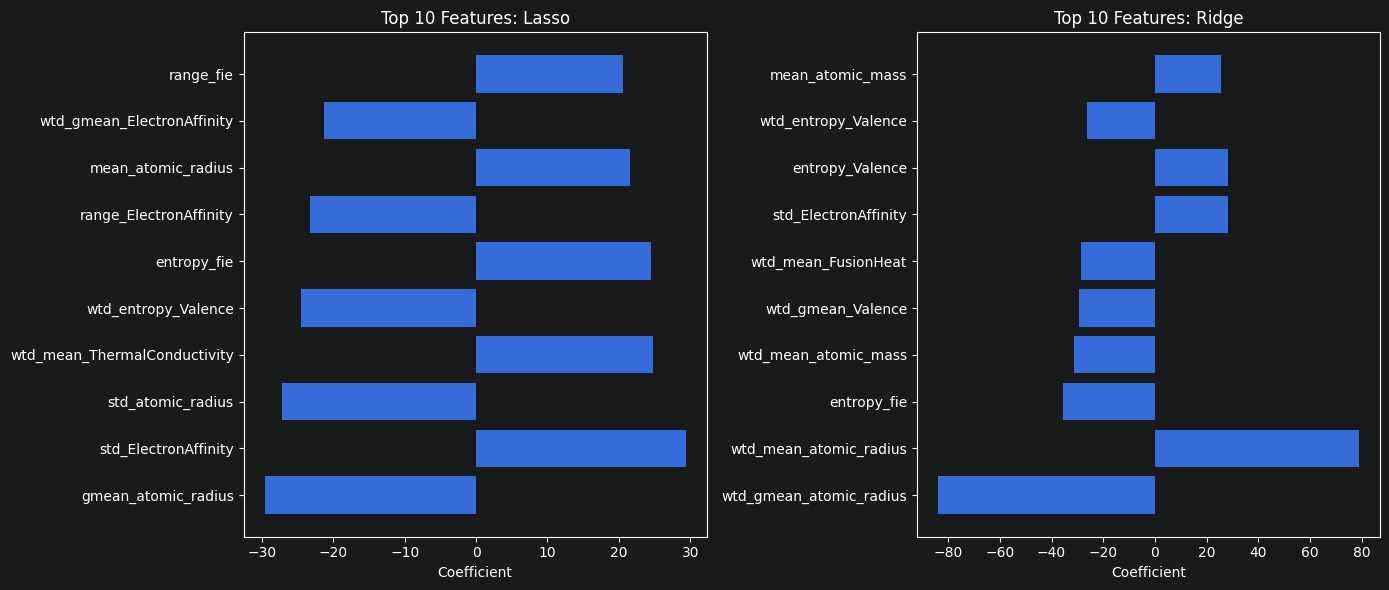

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(lasso_top10['feature'], lasso_top10['coefficient'])
axes[0].set_title('Top 10 Features: Lasso')
axes[0].set_xlabel('Coefficient')

axes[1].barh(ridge_top10['feature'], ridge_top10['coefficient'])
axes[1].set_title('Top 10 Features: Ridge')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

## Conclusion

While neither regularization method improved meaningfully on the baseline linear regression model, the regularization process confirmed for us that the baseline model was not overfit, and the feature importance results give us interpretable insight into which material properties are most predictive of critical temperature.